BLOCO_5_SCIKIT_LEARN_LINEAR_REGRESSION

PASSO:1

In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: C:\Users\Utilizador\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


PASSO_2

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PASSO_3

In [4]:
df = yf.download("AAPL", start="2021-01-01", end="2026-06-30")[["Close"]].dropna()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2021-01-04,125.740860
2021-01-05,127.295502
2021-01-06,123.010529
2021-01-07,127.208038
2021-01-08,128.306000


In [5]:
df["retorno"] = df["Close"].pct_change()
df["target"] = df["retorno"].shift(-1)
df.head()

Price,Close,retorno,target
Ticker,AAPL,,
Date,,,
2021-01-04,125.740860,NaN,0.012364
2021-01-05,127.295502,0.012364,-0.033662
2021-01-06,123.010529,-0.033662,0.034123
2021-01-07,127.208038,0.034123,0.008631
2021-01-08,128.306000,0.008631,-0.023249


PASSO_4 

Features simples que o modelo vai usar

In [6]:
df["ret_1"] = df["retorno"].shift(1)
df["ret_2"] = df["retorno"].shift(2)
df["ret_3"] = df["retorno"].shift(3)
df["mm_5"] = df["Close"].rolling(5).mean()
df["mm_10"] = df["Close"].rolling(10).mean()
df["vol_5"] = df["retorno"].rolling(5).std()

In [7]:
df = df.dropna()
df.head()

Price,Close,retorno,target,ret_1,ret_2,ret_3,mm_5,mm_10,vol_5
Ticker,AAPL,,,,,,,,
Date,,,,,,,,,
2021-01-15,123.535210,-0.013731,0.005427,-0.015127,0.016227,-0.001396,125.288068,125.800127,0.015372
2021-01-19,124.205658,0.005427,0.032856,-0.013731,-0.015127,0.016227,125.064586,125.646606,0.013203
2021-01-20,128.286560,0.032856,0.036658,0.005427,-0.013731,-0.015127,125.692271,125.745712,0.020359
2021-01-21,132.989304,0.036658,0.016074,0.032856,0.005427,-0.013731,126.854353,126.743590,0.024726
2021-01-22,135.126953,0.016074,0.027684,0.036658,0.032856,0.005427,128.828737,127.535481,0.020646


separar x e y


In [8]:
X = df[["ret_1", "ret_2", "ret_3", "mm_5", "mm_10", "vol_5"]]
y = df["target"]

dividir entre treino e teste Porque shuffle=False?
Em finanças estás a trabalhar com séries temporais. Não queres misturar passado e futuro aleatoriamente. O modelo deve treinar no passado e testar no período mais recente. Essa cautela é fundamental em dados financeiros.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

PASSO_5

Ajustamento do modelo, previsões e avaliação do modelo

In [11]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0.01,-0.04,-0.01,-0. , 0. ,-0.14]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.008443
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[1570.42, 64.96, 0.6 , 0.59, 0.5 , 0.29]"


In [12]:
y_pred = modelo.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 0.010814194723740603
MSE: 0.00022702237918787235
R2: -0.0665181859068289


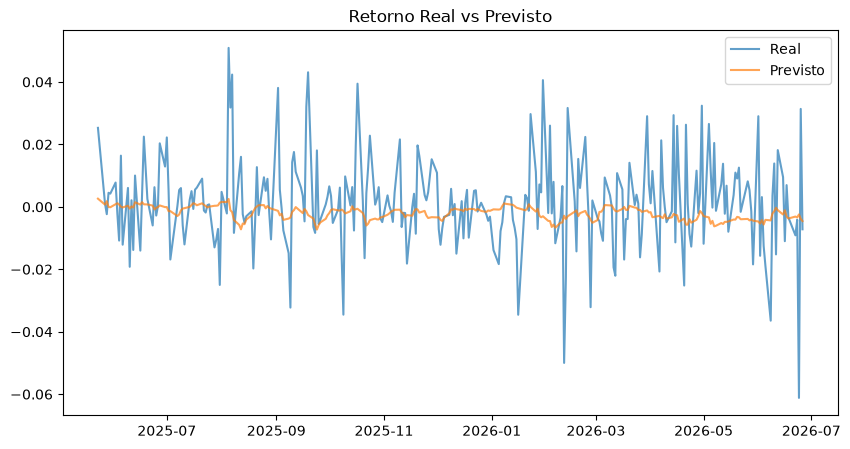

In [14]:
resultado = pd.DataFrame({
    "real": y_test,
    "previsto": y_pred
}, index=y_test.index)

resultado.head()
plt.figure(figsize=(10,5))
plt.plot(resultado.index, resultado["real"], label="Real", alpha=0.7)
plt.plot(resultado.index, resultado["previsto"], label="Previsto", alpha=0.7)
plt.legend()
plt.title("Retorno Real vs Previsto")
plt.show()

EXERCICIO_PRATICO

[*********************100%***********************]  1 of 1 completed


MAE: 0.01332815434058891
MSE: 0.00036806938638418225
R2: -0.014753471030493737


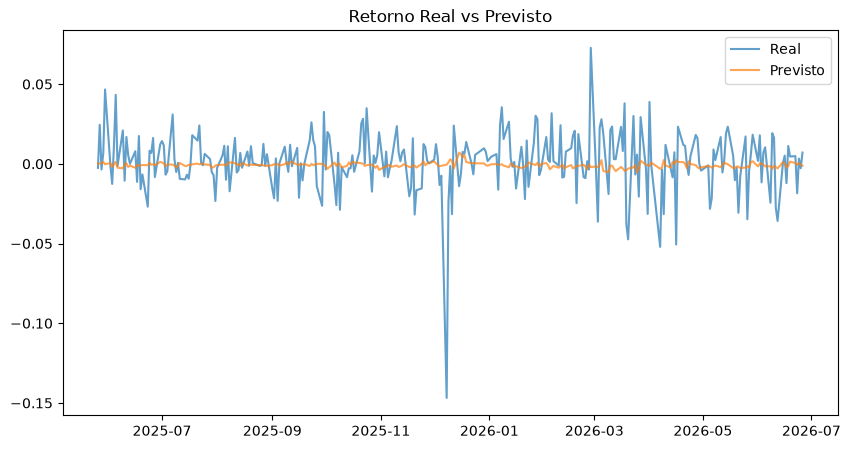

In [16]:
df = yf.download("GALP.LS", start="2021-01-01", end="2026-06-30")[["Close"]].dropna()
df.head()
df["retorno"] = df["Close"].pct_change()
df["target"] = df["retorno"].shift(-1)
df.head()
df["ret_1"] = df["retorno"].shift(1)
df["ret_2"] = df["retorno"].shift(2)
df["ret_3"] = df["retorno"].shift(3)
df["mm_5"] = df["Close"].rolling(5).mean()
df["mm_10"] = df["Close"].rolling(10).mean()
df["vol_5"] = df["retorno"].rolling(5).std()
df = df.dropna()
df.head()
X = df[["ret_1", "ret_2", "ret_3", "mm_5", "mm_10", "vol_5"]]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

resultado = pd.DataFrame({
    "real": y_test,
    "previsto": y_pred
}, index=y_test.index)

resultado.head()
plt.figure(figsize=(10,5))
plt.plot(resultado.index, resultado["real"], label="Real", alpha=0.7)
plt.plot(resultado.index, resultado["previsto"], label="Previsto", alpha=0.7)
plt.legend()
plt.title("Retorno Real vs Previsto")
plt.show()


BLOCO_5.2_LOGISTIC_REGRESSION

Classificação Binaria se o proximo retorno é positivo ou negativo

PASSO_1


In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report